# 3d volume recovery


In [1]:
from pathlib import Path
import sys
import time

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import mitsuba as mi
import drjit as dr

mi.set_variant('cuda_ad_rgb')
from mitsuba import ScalarTransform4f as T

folder = Path.cwd()
if not (folder / 'filters.py').exists():
    folder = folder / '3d_volume'
    
sys.path.insert(0, str(folder.parent))
sys.path.insert(0, str(folder))

from filters import cross_bilateral_filter, laplacian_smoothing_filter
from optimizers import adam_optimizer, spatiotemporal_optimizer

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'legend.fontsize': 8,
})

jitc_llvm_init(): LLVM API initialization failed ..


In [2]:
data = folder / 'data' / 'janga'
grid_size, view_count, render_res = 64, 64, 128
reference_spp, spp, spp_grad = 128, 16, 1

sigmat_key = 'object.interior_medium.sigma_t.data'
albedo_key = 'object.interior_medium.albedo.data'


batch = {'type': 'batch'}
for i in range(view_count):
    batch[f'sensor{i}'] = {
        'type': 'perspective',
        'fov': 45,
        'to_world': T.rotate([0, 1, 0], 360.0 / view_count * i)
                    @ T.look_at(target=[0, 0, 0], origin=[0, 0, 4], up=[0, 1, 0]),
    }
# box reconstruction filter, theirs. mitsuba defaults to gaussian which blurs across
# pixels and would change both the image and the gradients
batch['film'] = {'type': 'hdrfilm', 'width': render_res * view_count,
                 'height': render_res, 'filter': {'type': 'box'}, 'pixel_format': 'rgba'}
batch_sensor = mi.load_dict(batch)

envmap = {'type': 'envmap', 'filename': str(data / 'autumn_field_puresky_1k.exr')}


def build_scene(sigmat, albedo):
    '''cube of participating media lit by an envmap, with the two grids we optimize'''
    return mi.load_dict({
        'type': 'scene',
        'integrator': {'type': 'prbvolpath'},
        'object': {
            'type': 'cube',
            'bsdf': {'type': 'null'},
            'interior': {
                'type': 'heterogeneous',
                'sigma_t': {'type': 'gridvolume', 'grid': mi.VolumeGrid(sigmat),
                            'to_world': T.translate(-1).scale(2.0)},
                'albedo': {'type': 'gridvolume', 'grid': mi.VolumeGrid(albedo),
                           'to_world': T.translate(-1).scale(2.0)},
                'scale': 40.0,
            },
        },
        'emitter': envmap,
    })

In [3]:
def resample(volume, size):
    tensor = torch.tensor(np.asarray(volume, dtype=np.float32))

    if tensor.shape[3] == 1:
        tensor = tensor.squeeze(-1).unsqueeze(0).unsqueeze(0)
        tensor = F.interpolate(tensor, (size,) * 3, mode='trilinear')
        return tensor.squeeze().unsqueeze(-1).numpy()

    tensor = tensor.permute(3, 0, 1, 2).unsqueeze(0)
    tensor = F.interpolate(tensor, (size,) * 3, mode='trilinear')
    return tensor.squeeze().permute(1, 2, 3, 0).numpy()



to_world = T.rotate([1, 0, 0], -90).scale(2).translate(-0.5)

loader = mi.load_dict({
    'type': 'scene',
    'integrator': {'type': 'prbvolpath'},
    'object': {'type': 'cube', 'bsdf': {'type': 'null'},
               'interior': {'type': 'heterogeneous',
                            'sigma_t': {'type': 'gridvolume',
                                        'filename': str(data / 'janga-smoke-264-136-136.vol'),
                                        'to_world': to_world},
                            'albedo': {'type': 'gridvolume',
                                       'filename': str(data / 'albedo-noise-256-128-128.vol'),
                                       'to_world': to_world},
                            'scale': 40}},
    'emitter': envmap,
})
loaded = mi.traverse(loader)

sigmat_ref = resample(loaded[sigmat_key], grid_size)
albedo_ref = resample(loaded[albedo_key], grid_size)

scene_ref = build_scene(mi.TensorXf(sigmat_ref), mi.TensorXf(albedo_ref))
reference_image = mi.render(scene_ref, sensor=batch_sensor, spp=reference_spp)

In [4]:
scene = build_scene(mi.TensorXf(np.full((grid_size,) * 3 + (1,), 0.002, np.float32)),
                    mi.TensorXf(np.full((grid_size,) * 3 + (3,), 0.6, np.float32)))
params = mi.traverse(scene)


def render_gradient(sigmat, albedo, iteration):
    '''
    render all 64 views with the current volumes and backprop the loss to both grids

    sigmat: (64, 64, 64, 1) density
    albedo: (64, 64, 64, 3) single scattering albedo
    iteration: used as the render seed so each iteration draws fresh samples
    '''
    sigmat_tensor = mi.TensorXf(sigmat.astype(np.float32))
    albedo_tensor = mi.TensorXf(albedo.astype(np.float32))
    dr.enable_grad(sigmat_tensor)
    dr.enable_grad(albedo_tensor)

    params[sigmat_key] = sigmat_tensor
    params[albedo_key] = albedo_tensor
    params.update()

    image = mi.render(scene, params, sensor=batch_sensor, spp=spp, spp_grad=spp_grad, seed=iteration + 1)
    loss = dr.mean(dr.square(image[..., :3] - reference_image[..., :3]))
    dr.backward(loss)

    return np.array(dr.grad(sigmat_tensor)), np.array(dr.grad(albedo_tensor)), float(np.array(loss))

In [5]:
class self_guided_filter:
    '''turns cross bilateral into standard bilateral by guiding on what is being filtered (e.g. m_t)'''

    def __init__(self, filter):
        self.filter = filter

    def __call__(self, h, guide=None):
        return self.filter(h, h)


def run_optimizer(make_optimizer, iterations, lr_half_iters=(50, 100, 150)):
    '''
    optimize density and albedo 
    '''
    sigmat = np.full((grid_size,) * 3 + (1,), 0.002)
    albedo = np.full((grid_size,) * 3 + (3,), 0.6)

    optimizers = {'sigmat': make_optimizer('sigmat'), 'albedo': make_optimizer('albedo')}
    losses, sigmat_errors, albedo_errors = [], [], []

    for iteration in range(iterations):
        if iteration in lr_half_iters:
            for optimizer in optimizers.values():
                optimizer.lr /= 2.0

        sigmat_grad, albedo_grad, loss = render_gradient(sigmat, albedo, iteration)

        sigmat = np.clip(optimizers['sigmat'].step(sigmat, sigmat_grad), 1e-6, 1.0)
        albedo = np.clip(optimizers['albedo'].step(albedo, albedo_grad), 0.0, 1.0)

        losses.append(loss)
        sigmat_errors.append(np.mean(np.abs(sigmat - sigmat_ref)))
        albedo_errors.append(np.mean(np.abs(albedo - albedo_ref)))

    return {'sigmat': sigmat, 'albedo': albedo, 'loss': np.array(losses),
            'sigmat_error': np.array(sigmat_errors), 'albedo_error': np.array(albedo_errors)}

In [6]:
iterations = 50      
eps = 1e-15          


def betas(beta_1):
    return beta_1, 1.0 - (1 - beta_1) ** 2


b1, b2 = betas(0.2)

cross_sigma_d = {'sigmat': 1e-3, 'albedo': 2e-1}
bilateral_sigma_d = {'sigmat': 1e-3, 'albedo': 2e-7}

def adam(name):
    return adam_optimizer(lr=0.008, b_1=b1, b_2=b2, eps=eps)


def laplacian(name):
    return spatiotemporal_optimizer(lr=0.02, b_1=b1, b_2=b2, eps=eps,
                                    filter=laplacian_smoothing_filter(passes=3))


def bilateral(name):
    return spatiotemporal_optimizer(
        lr=0.02, b_1=b1, b_2=b2, eps=eps,
        filter=self_guided_filter(cross_bilateral_filter(sigma_data=bilateral_sigma_d[name], passes=3)))


def cross_bilateral(name):
    return spatiotemporal_optimizer(
        lr=0.02, b_1=b1, b_2=b2, eps=eps,
        filter=cross_bilateral_filter(sigma_data=cross_sigma_d[name], passes=3))


methods = {
    'adam': adam,
    'laplacian': laplacian,
    'bilateral': bilateral,
    'cross bilateral': cross_bilateral,
}

recoveries = {}
for name, make_optimizer in methods.items():
    start = time.perf_counter()
    recoveries[name] = run_optimizer(make_optimizer, iterations)
    print(f'{name:16s} loss {recoveries[name]["loss"][-1]:.6f}'
          f'  sigma_t err {recoveries[name]["sigmat_error"][-1]:.5f}'
          f'  albedo err {recoveries[name]["albedo_error"][-1]:.5f}'
          f'  ({time.perf_counter() - start:.0f}s)')

adam             loss 0.002815  sigma_t err 0.06040  albedo err 0.27348  (17s)
laplacian        loss 0.005876  sigma_t err 0.06418  albedo err 0.22503  (967s)
bilateral        loss 0.005949  sigma_t err 0.06531  albedo err 0.24550  (979s)
cross bilateral  loss 0.001851  sigma_t err 0.05576  albedo err 0.20234  (990s)


In [18]:
method_titles = {
    'adam': '(a) adam',
    'laplacian': '(b) laplacian smoothing',
    'bilateral': '(c) bilateral filter',
    'cross bilateral': '(d) cross-bilateral filter',
}
method_colors = {
    'adam': '#1982c4',
    'laplacian': '#2ca25f',
    'bilateral': '#f5a400',
    'cross bilateral': '#ff595e',
}


def render_view(sigmat, albedo, view=0, samples=128):
    rendered = np.array(mi.render(build_scene(mi.TensorXf(sigmat.astype(np.float32)),
                                              mi.TensorXf(albedo.astype(np.float32))),
                                  sensor=batch_sensor, spp=samples))
    return rendered[:, view * render_res:(view + 1) * render_res, :3]


def plot_recoveries(recoveries, view=0, title='Inverse volume recovery (50 iterations)'):
    names = list(recoveries)
    figure, axes = plt.subplots(1, len(names) + 1, figsize=(2.05 * (len(names) + 1), 2.4),
                                layout='constrained')
    for axis in axes.ravel():
        axis.set_axis_off()

    for axis, name in zip(axes, names):
        result = recoveries[name]
        axis.imshow(np.clip(render_view(result['sigmat'], result['albedo'], view) ** (1 / 2.2), 0, 1))
        axis.set_title(method_titles[name], fontsize=9, pad=6)

    reference_view = np.array(reference_image)[:, view * render_res:(view + 1) * render_res, :3]
    axes[-1].imshow(np.clip(reference_view ** (1 / 2.2), 0, 1))
    axes[-1].set_title('(e) reference', fontsize=9, pad=6)

    figure.suptitle(title, fontsize=13)
    return figure


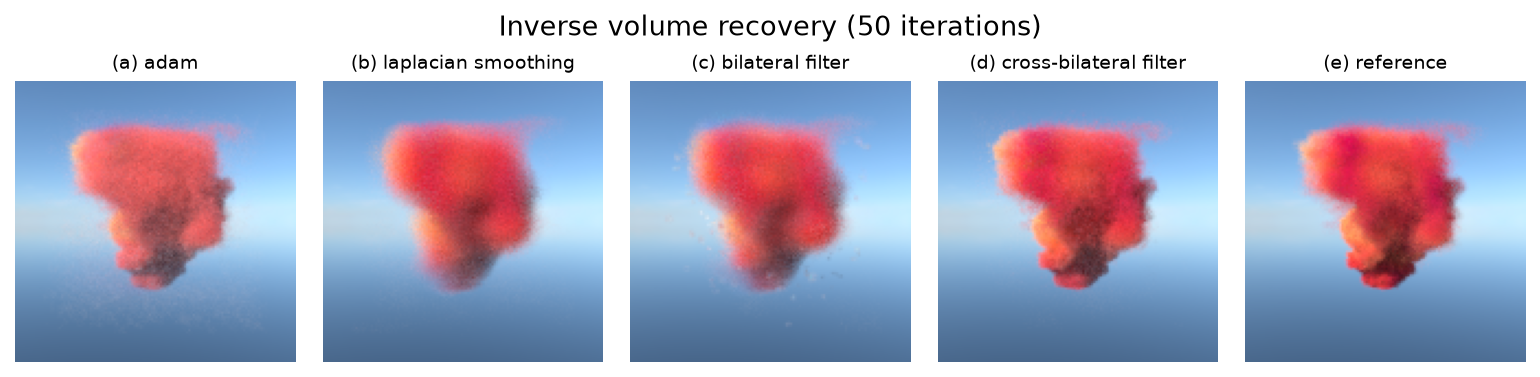

In [19]:
plot_recoveries(recoveries);